# Student Focus Monitoring -- 4-Class Model Training

Classes: **Focused / Fatigue / Anxiety / Boredom**

## Two models, because the data is two different things

`inference.py` finds a **face** with a Haar cascade, pads it 15% and feeds a 224x224 crop to the
model. That is the only kind of image the deployed system ever produces, so it decides which data can
train the main model:

| Dataset | Content | Used for |
|---|---|---|
| Student Behavior Detection | 640x640 face crops (DAiSEE) | **stage 1** -- Focused, Boredom, Anxiety |
| fatigue | 1920x1080 webcam frames | **stage 1** -- Fatigue, Focused |
| facial | 96x96 FER emotion crops | **stage 1** -- Anxiety, Focused |
| eye | 82x82 **eye patches** | **stage 2** -- a separate awake/sleepy model |

The eye images are not faces. Folding 84,898 eye patches into the face model would swamp the ~11k
face images 8:1 and teach it to read eye texture, which never reaches it at inference. So they train
a second, independent awake/sleepy model (section 10) that the backend can run on the eye region as
extra Fatigue evidence.

`facial/tired` is 1,436 images that are **byte-identical to images already in `fatigue`** -- the
dedup step in section 2 removes them, which is why `fatigue` is scanned first and keeps the record.

## Stage-1 pipeline

| # | Step | What happens |
|---|------|--------------|
| 1 | Scan | walk the three face datasets, map their native labels onto the 4 classes |
| 2 | Clean | drop byte-identical duplicates and label-conflicting images |
| 3 | Split | subject-disjoint 70/15/15 |
| 4/5b | Balance | image augmentation *or* SMOTE on features -- `BALANCE_METHOD` picks |
| 5 | Features | frozen MobileNetV2, 1280-d, cached to disk |
| 6 | Train | Random Forest / XGBoost / SVM |
| 7 | Evaluate | macro-F1 picks the winner; charts, per-source audit, clip-level voting |
| 8 | Save | artifacts under the exact names `inference.py` loads |
| 10 | Stage 2 | the separate eye awake/sleepy model |

Every shipped split in every one of these datasets leaks subjects across train and test -- all 37 eye
subjects appear in all three of its folders, and 28 of 29 SBD test subjects are also in its train
folder. Frames of one person are near-identical, so the shipped splits score a model on faces it has
already memorised. All splits here are rebuilt subject-disjoint.

Run top to bottom. Feature extraction is the slow part and is cached; set `REBUILD_CACHE = True` to
force re-extraction.

## 0. Imports and settings

In [1]:
import hashlib
import json
import random
import re
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

print("imports ok")

imports ok


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Notebook lives in backend/ml_scripts/focus/ -> backend/ is two levels up.
# Fall back to the current working directory when __file__ is unavailable.
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    BASE_DIR = Path.cwd()
    while BASE_DIR.name != "backend" and BASE_DIR.parent != BASE_DIR:
        BASE_DIR = BASE_DIR.parent

DATASETS     = BASE_DIR / "datasets" / "focus"
SBD_PATH     = DATASETS / "Student Behavior Detection"
FATIGUE_PATH = DATASETS / "fatigue"
FACIAL_PATH  = DATASETS / "facial" / "processed_data"
EYE_PATH     = DATASETS / "eye" / "data"
OUTPUT_PATH  = BASE_DIR / "trained-models" / "focus"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

CLASSES      = ["Focused", "Fatigue", "Anxiety", "Boredom"]
IMG_SIZE     = 224
BATCH_SIZE   = 32
IMG_EXTS     = (".jpg", ".jpeg", ".png", ".bmp")
SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}
CACHE_FILE   = OUTPUT_PATH / "features_cache.npz"

# How the training set is balanced. val/test are NEVER balanced.
#   "augment" - oversample images, each extra copy randomly flipped/rotated/etc.
#               (step 4, before feature extraction)
#   "smote"   - synthesise new 1280-d feature vectors between real neighbours
#               (step 5b, after feature extraction)
#   "none"    - leave the natural distribution, lean on class_weight instead
BALANCE_METHOD = "smote"

# Sources allowed into train but never into val/test.
#
# `facial` is 96x96 FER crops, and the only classes it carries are Anxiety and
# Focused. Scored against it the model gets credit for spotting "small grainy
# crop => Anxiety", which is a property of the source rather than of the
# student. inference.py only ever produces a padded face crop, so keeping facial
# out of val/test makes the reported score describe the images the backend will
# actually send. Its Anxiety examples still train the model.
TRAIN_ONLY_SOURCES = {"facial"}

REBUILD_CACHE = False   # True -> re-extract MobileNetV2 features from the images

print(f"BASE_DIR : {BASE_DIR}")
for _n, _p in [("sbd", SBD_PATH), ("fatigue", FATIGUE_PATH),
               ("facial", FACIAL_PATH), ("eye", EYE_PATH)]:
    print(f"  {_n:<8} {'ok ' if _p.is_dir() else 'MISSING'} {_p}")
print(f"output   : {OUTPUT_PATH}")
print(f"classes  : {', '.join(CLASSES)}")
print(f"balance  : {BALANCE_METHOD}")

BASE_DIR : c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend
  sbd      ok  c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus\Student Behavior Detection
  fatigue  ok  c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus\fatigue
  facial   ok  c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus\facial\processed_data
  eye      ok  c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus\eye\data
output   : c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus
classes  : Focused, Fatigue, Anxiety, Boredom
balance  : smote


### Label maps

Each source dataset has its own vocabulary; all three face datasets are folded onto the 4 classes.

- **Confusion joins Frustration under Anxiety** -- both are negative-arousal affect in DAiSEE terms,
  and merging lifts the otherwise very thin Anxiety class.
- **`non_vigilant` joins `tired` under Fatigue** -- drowsy-but-not-asleep still reads as fatigue at
  inference time.
- **`facial` is mapped conservatively.** angry / fear / disgust go to Anxiety because all three are
  negative-arousal affect, and neutral goes to Focused. **happy and surprise are deliberately left
  out**: neither maps onto an engagement state without inventing a meaning for it, and a wrong label
  costs more than a missing one. `tired` maps to Fatigue but is entirely duplicated inside `fatigue`,
  so section 2 removes it.

Note what none of these datasets supplies: **new Boredom data**. Boredom comes from SBD alone and is
the weakest class, and no dataset here changes that.

In [3]:
SBD_MAP = {
    "Engagement":  "Focused",
    "Boredom":     "Boredom",
    "Frustration": "Anxiety",
    "Confusion":   "Anxiety",
}

FATIGUE_MAP = {
    "alert":        "Focused",
    "tired":        "Fatigue",
    "non_vigilant": "Fatigue",
}

# happy / surprise are intentionally absent -- see the note above.
FACIAL_MAP = {
    "angry":   "Anxiety",
    "fear":    "Anxiety",
    "disgust": "Anxiety",
    "neutral": "Focused",
    "tired":   "Fatigue",   # duplicated inside `fatigue`; dedup drops it
}

# Subject/session id embedded in the filename, used to keep one person's frames
# inside a single split.
#   SBD     : cropped_face_0_1100021015_frame_105-Copie_jpg.rf.<hash>.jpg
#   fatigue : 1001_frame1.jpg
SBD_ID_RE     = re.compile(r"_(\d+)_frame")
FATIGUE_ID_RE = re.compile(r"^(\d+)_frame")


def sbd_group(name):
    """DAiSEE clip ids are 10 digits whose first 6 identify the person, so group
    on those. Other id lengths come from a different capture session and are
    grouped whole. None when the filename carries no usable id."""
    m = SBD_ID_RE.search(name)
    if not m:
        return None
    cid = m.group(1)
    if len(cid) < 4:            # 'cropped_face_0_frame_112...' -> no real id
        return None
    return f"sbd:{cid[:6]}" if len(cid) == 10 else f"sbd:{cid}"


def fatigue_group(name):
    m = FATIGUE_ID_RE.match(name)
    return f"fat:{m.group(1)}" if m else None

# A *group* is a person (frames of one person must not straddle the split).
# A *clip* is one recording segment of that person, which carries a single
# label -- that is the unit clip-level voting pools over, and it is finer than
# the group: one person contributes several clips, often in different states.
#
#   SBD     : the full 10-digit DAiSEE id IS the clip, and one clip has one label
#   fatigue : filenames carry only the subject, so the label folder is what
#             separates that subject's alert frames from their tired ones
def facial_group(name):
    """FER crops carry no subject id, so they cannot be grouped -- they get split
    at the plain ratios. facial/tired filenames follow the fatigue convention,
    so those reuse fatigue_group and stay with their subject."""
    return fatigue_group(name)


def clip_id(path, source, src_label):
    m = (SBD_ID_RE.search(path.name) if source == "sbd"
         else FATIGUE_ID_RE.match(path.name))
    # The <4-digit guard matters as much here as in sbd_group: names like
    # 'cropped_face_0_frame_112...' make the regex capture "0", and without the
    # guard every such frame collapses into one enormous fake clip.
    if not m or len(m.group(1)) < 4:
        return f"solo:{source}:{path.name}"   # unpooled: its own clip of one
    return f"{source}:{m.group(1)}:{src_label}"

## 1. Scan the datasets

Walk both dataset trees and build one flat record list: `{path, label, group, source}`.
The shipped train/valid/test folders are flattened here — the split is rebuilt from scratch in step 3.

In [4]:
def scan(root, label_map, group_fn, source, split_names):
    """-> list of {path, label, group, source} for one dataset."""
    records = []
    if not root.is_dir():
        print(f"   !! missing {root}")
        return records
    for split in split_names:
        for src_label, target in label_map.items():
            d = root / split / src_label
            if not d.is_dir():
                continue
            for p in sorted(d.rglob("*")):
                if p.suffix.lower() in IMG_EXTS:
                    records.append({"path":   p,
                                    "label":  target,
                                    "group":  group_fn(p.name),
                                    "clip":   clip_id(p, source, src_label),
                                    "source": source})
    return records


def scan_facial(root, label_map, group_fn, source, split_names):
    """Same as scan(), for the <label>/<split>/ layout facial uses (the others
    are <split>/<label>/)."""
    records = []
    if not root.is_dir():
        print(f"   !! missing {root}")
        return records
    for src_label, target in label_map.items():
        for split in split_names:
            d = root / src_label / split
            if not d.is_dir():
                continue
            for p in sorted(d.rglob("*")):
                if p.suffix.lower() in IMG_EXTS:
                    records.append({"path":   p,
                                    "label":  target,
                                    "group":  group_fn(p.name),
                                    "clip":   clip_id(p, source, src_label),
                                    "source": source})
    return records


sbd = scan(SBD_PATH, SBD_MAP, sbd_group, "sbd", ("train", "valid", "test"))
fat = scan(FATIGUE_PATH, FATIGUE_MAP, fatigue_group, "fatigue", ("train", "val", "test"))
fac = scan_facial(FACIAL_PATH, FACIAL_MAP, facial_group, "facial", ("train", "val", "test"))

# facial goes LAST on purpose: dedup keeps the first copy it sees, and the
# facial/tired images are duplicates of fatigue ones. Scanning fatigue first
# means the surviving record keeps the fatigue subject group.
records = sbd + fat + fac

if not records:
    raise SystemExit("No images found -- check the dataset paths printed above.")

print(f"sbd={len(sbd)}  fatigue={len(fat)}  facial={len(fac)}  total={len(records)}\n")
for s in ("sbd", "fatigue", "facial"):
    c = Counter(r["label"] for r in records if r["source"] == s)
    print(f"  {s:<8} " + "  ".join(f"{k}={v}" for k, v in sorted(c.items())))
print()
for cls, n in Counter(r["label"] for r in records).most_common():
    print(f"  {cls:<9} {n:>6}")

sbd=6174  fatigue=3907  facial=7180  total=17261

  sbd      Anxiety=939  Boredom=855  Focused=4380
  fatigue  Fatigue=2655  Focused=1252
  facial   Anxiety=4308  Fatigue=1436  Focused=1436

  Focused     7068
  Anxiety     5247
  Fatigue     4091
  Boredom      855


### Peek at a few raw samples

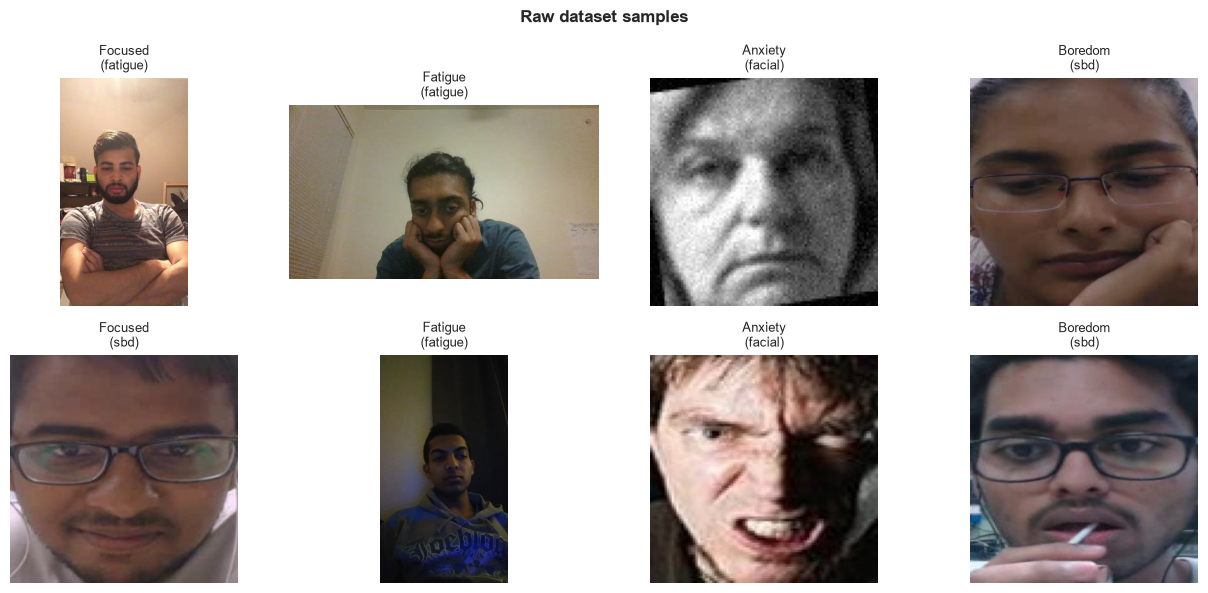

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
by_cls = defaultdict(list)
for r in records:
    by_cls[r["label"]].append(r)

for col, cls in enumerate(CLASSES):
    for row in range(2):
        ax = axes[row][col]
        picks = by_cls.get(cls, [])
        if picks:
            r = random.Random(SEED + row * 10 + col).choice(picks)
            img = cv2.imread(str(r["path"]))
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{cls}\n({r['source']})", fontsize=9)
        ax.axis("off")

plt.suptitle("Raw dataset samples", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Clean — deduplicate and drop label conflicts

Both datasets contain repeated frames, and the same image sometimes appears under two different
labels (a genuine annotation conflict). Byte-identical copies are collapsed via MD5; if the copies
disagree on the label, the record is dropped entirely rather than guessed at.

This cell hashes every file, so it takes a minute or two on a cold disk.

In [6]:
def file_hash(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while blk := f.read(chunk):
            h.update(blk)
    return h.hexdigest()


def deduplicate(records):
    """Collapse byte-identical images; drop any whose copies disagree on label."""
    seen, unique, dups, conflicts = {}, [], 0, 0

    for i, r in enumerate(records, 1):
        if i % 2000 == 0:
            print(f"   hashing {i}/{len(records)}", end="\r")
        h    = file_hash(r["path"])
        prev = seen.get(h)
        if prev is None:
            seen[h] = r
            unique.append(r)
        else:
            dups += 1
            if prev["label"] != r["label"]:
                prev["_conflict"] = True
                conflicts += 1

    before = len(unique)
    unique = [r for r in unique if not r.get("_conflict")]
    print(f"   hashing {len(records)}/{len(records)} done      ")
    print(f"   duplicates removed       : {dups}")
    print(f"   label-conflicting images : {conflicts} (dropped {before - len(unique)} records)")
    print(f"   unique images kept       : {len(unique)}")
    return unique


unique = deduplicate(records)

print()
for cls, n in Counter(r["label"] for r in unique).most_common():
    print(f"  {cls:<9} {n:>6}")

   hashing 17261/17261 done      
   duplicates removed       : 1436
   label-conflicting images : 0 (dropped 0 records)
   unique images kept       : 15825

  Focused     7068
  Anxiety     5247
  Fatigue     2655
  Boredom      855


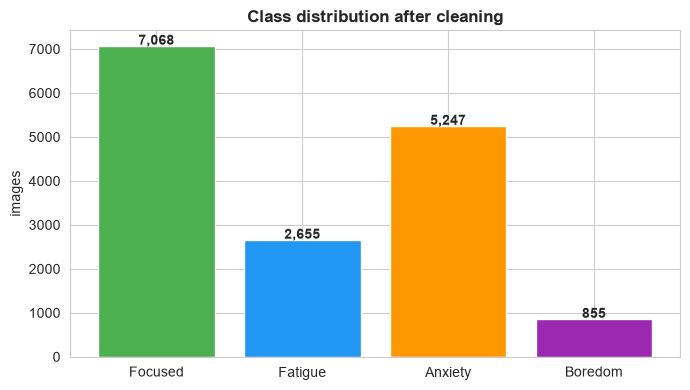

In [7]:
counts = Counter(r["label"] for r in unique)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASSES, [counts[c] for c in CLASSES],
              color=["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"], edgecolor="white")
for b, c in zip(bars, CLASSES):
    ax.text(b.get_x() + b.get_width() / 2, counts[c] + 30, f"{counts[c]:,}",
            ha="center", fontweight="bold")
ax.set_ylabel("images")
ax.set_title("Class distribution after cleaning", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Subject-disjoint split (70 / 15 / 15)

A subject shows several states, so their frames appear under multiple classes. Groups are therefore
assigned **once, globally** — assigning them per class would put the same person in `train` for one
label and `test` for another, which leaks just as badly.

Groups are placed greedily: the split that is relatively emptiest (measured as a fraction of its
quota, not raw overflow) takes the next group, which preserves the 70/15/15 shape per class.
Largest groups go first because they constrain the most.

In [8]:
def build_splits(unique):
    # Train-only sources are set aside before quotas are computed, so they
    # neither claim val/test places nor distort the 70/15/15 shape of the
    # sources that do get evaluated.
    held = [r for r in unique if r["source"] in TRAIN_ONLY_SOURCES]
    unique = [r for r in unique if r["source"] not in TRAIN_ONLY_SOURCES]

    grouped   = defaultdict(list)   # group -> [rec] across all classes
    ungrouped = defaultdict(list)   # label -> [rec]

    for r in unique:
        if r["group"]:
            grouped[r["group"]].append(r)
        else:
            ungrouped[r["label"]].append(r)

    split_of     = {}
    class_totals = Counter(r["label"] for r in unique)
    quota  = {s: {c: SPLIT_RATIOS[s] * class_totals[c] for c in CLASSES} for s in SPLIT_RATIOS}
    filled = {s: {c: 0.0 for c in CLASSES} for s in SPLIT_RATIOS}

    def cost(split, counts):
        """Worst-case proportional fill if `split` takes a group with `counts`."""
        return max((filled[split][c] + n) / max(quota[split][c], 1.0)
                   for c, n in counts.items())

    groups = list(grouped.values())
    random.Random(SEED).shuffle(groups)
    groups.sort(key=len, reverse=True)   # largest groups constrain the most

    for recs in groups:
        cnts = Counter(r["label"] for r in recs)
        pick = min(SPLIT_RATIOS, key=lambda s: cost(s, cnts))
        for r in recs:
            split_of[id(r)] = pick
            filled[pick][r["label"]] += 1

    # Id-less files cannot be grouped; split them per class at the plain ratios.
    for cls in CLASSES:
        loose = ungrouped[cls][:]
        random.Random(SEED).shuffle(loose)
        n_tr = int(len(loose) * SPLIT_RATIOS["train"])
        n_va = int(len(loose) * SPLIT_RATIOS["val"])
        for r in loose[:n_tr]:
            split_of[id(r)] = "train"
        for r in loose[n_tr:n_tr + n_va]:
            split_of[id(r)] = "val"
        for r in loose[n_tr + n_va:]:
            split_of[id(r)] = "test"

    splits = {"train": [], "val": [], "test": []}
    for r in unique:
        splits[split_of[id(r)]].append(r)
    splits["train"].extend(held)
    if held:
        print(f"   {len(held)} train-only records "
              f"({', '.join(sorted(TRAIN_ONLY_SOURCES))}) appended to train\n")
    return splits


splits = build_splits(unique)

print(f"   {'Class':<9}{'Train':>8}{'Val':>7}{'Test':>7}{'Total':>8}")
print("   " + "-" * 39)
for cls in CLASSES:
    c = {s: sum(1 for r in splits[s] if r["label"] == cls) for s in splits}
    print(f"   {cls:<9}{c['train']:>8}{c['val']:>7}{c['test']:>7}{sum(c.values()):>8}")
print("   " + "-" * 39)
print(f"   {'TOTAL':<9}{len(splits['train']):>8}{len(splits['val']):>7}"
      f"{len(splits['test']):>7}"
      f"{sum(len(v) for v in splits.values()):>8}")

gs = {s: {r["group"] for r in splits[s] if r["group"]} for s in splits}
print("\n   subject-group overlap (must all be 0):")
print(f"     train vs val : {len(gs['train'] & gs['val'])}")
print(f"     train vs test: {len(gs['train'] & gs['test'])}")
print(f"     val   vs test: {len(gs['val']   & gs['test'])}")

   5744 train-only records (facial) appended to train

   Class       Train    Val   Test   Total
   ---------------------------------------
   Focused      5378    844    846    7068
   Fatigue      1861    397    397    2655
   Anxiety      4963    141    143    5247
   Boredom       599    127    129     855
   ---------------------------------------
   TOTAL       12801   1509   1515   15825

   subject-group overlap (must all be 0):
     train vs val : 0
     train vs test: 0
     val   vs test: 0


## 4. Balance the training set

Only the **train** split is ever balanced -- val and test keep their natural distribution so the
reported scores reflect real-world class frequencies.

Two strategies are wired up, selected by `BALANCE_METHOD` in the settings cell:

| `BALANCE_METHOD` | Where it acts | How |
|---|---|---|
| `"augment"` | on **images**, before feature extraction | oversample minority files, each extra copy randomly flipped / rotated / brightness-shifted / zoomed |
| `"smote"` | on **features**, after extraction (step 5b) | synthesise new 1280-d vectors by interpolating between a minority sample and its k nearest minority neighbours |
| `"none"` | nowhere | leave the imbalance, rely on `class_weight="balanced"` in the models |

They are **alternatives, not a stack** -- running both would balance twice and over-represent
whatever was rarest.

The functions below are used by the `"augment"` path. Images are never held in RAM: `build_items`
returns paths plus an "augment me" flag, and the decode happens inside the feature-extraction loop.

In [9]:
def augment(img):
    """flip / rotation / brightness / zoom"""
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)

    h, w = img.shape[:2]
    M    = cv2.getRotationMatrix2D((w / 2, h / 2), np.random.uniform(-15, 15), 1.0)
    img  = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    img = np.clip(img.astype(np.float32) * np.random.uniform(0.7, 1.3), 0, 255).astype(np.uint8)

    if np.random.rand() > 0.5:
        z      = np.random.uniform(0.85, 1.0)
        ch, cw = int(h * z), int(w * z)
        y1     = np.random.randint(0, h - ch + 1)
        x1     = np.random.randint(0, w - cw + 1)
        img    = cv2.resize(img[y1:y1 + ch, x1:x1 + cw], (w, h))

    return img


def build_items(recs, balance=False):
    """-> [(path, label, source, clip, do_augment)], images never held in RAM."""
    items = [(r["path"], r["label"], r["source"], r["clip"], False) for r in recs]

    if balance:
        by_cls = defaultdict(list)
        for r in recs:
            by_cls[r["label"]].append(r)
        target = max(len(v) for v in by_cls.values())
        for cls in CLASSES:
            rs = by_cls.get(cls)
            if not rs:
                continue
            need = target - len(rs)
            for i in range(need):
                r = rs[i % len(rs)]
                items.append((r["path"], r["label"], r["source"], r["clip"], True))
            print(f"     {cls:<9} {len(rs):>6} -> {target} (aug +{need})")
        print(f"     balanced total: {len(items)}")

    random.Random(SEED).shuffle(items)
    return items

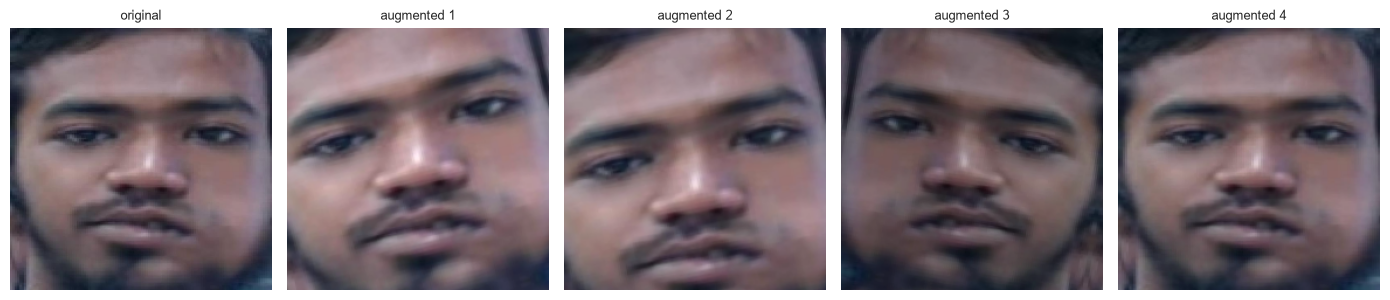

In [10]:
# What augmentation does to one image
sample = cv2.cvtColor(cv2.imread(str(splits["train"][0]["path"])), cv2.COLOR_BGR2RGB)
sample = cv2.resize(sample, (IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(sample); axes[0].set_title("original", fontsize=9)
for i in range(1, 5):
    axes[i].imshow(augment(sample.copy())); axes[i].set_title(f"augmented {i}", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Feature extraction — frozen MobileNetV2

Every image becomes a 1280-d embedding from ImageNet-pretrained MobileNetV2 (`include_top=False`,
`pooling="avg"`). The classical models in step 6 then train on those vectors, which is far cheaper
than fine-tuning a CNN and works well on a dataset this size.

The cache is keyed by a **signature** of the split — a cache built from a different split is
rejected rather than silently reused, otherwise the model would train on someone else's data.

In [11]:
def extract(mobilenet, items, tag):
    feats, labels, sources, clips = [], [], [], []
    total = len(items)

    for i in range(0, total, BATCH_SIZE):
        batch, imgs, keep = items[i:i + BATCH_SIZE], [], []
        for path, label, source, clip, do_aug in batch:
            img = cv2.imread(str(path))
            if img is None:
                continue
            img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
            if do_aug:
                img = augment(img)
            imgs.append(preprocess_input(img.astype(np.float32)))
            keep.append((label, source, clip))

        if not imgs:
            continue

        feats.extend(mobilenet.predict(np.array(imgs), verbose=0))
        labels.extend(l for l, _, _ in keep)
        sources.extend(s for _, s, _ in keep)
        clips.extend(c for _, _, c in keep)
        print(f"   {tag}: {min(i + BATCH_SIZE, total)}/{total}", end="\r")

    print(f"   {tag}: {total}/{total} done      ")
    return np.array(feats), np.array(labels), np.array(sources), np.array(clips)

In [12]:
# The cache must also key on BALANCE_METHOD: the "augment" path extracts extra
# augmented rows that the "smote" and "none" paths must not see.
signature = json.dumps({"classes": CLASSES,
                        "balance": BALANCE_METHOD,
                        "clips": True,
                        "splits": {s: dict(Counter(r["label"] for r in v))
                                   for s, v in splits.items()}},
                       sort_keys=True)

cached = None
if CACHE_FILE.exists() and not REBUILD_CACHE:
    c = np.load(CACHE_FILE, allow_pickle=True)
    needed = {"X_train", "y_train", "s_train", "c_train",
              "X_val", "y_val", "s_val", "c_val",
              "X_test", "y_test", "s_test", "c_test", "signature"}
    if not needed.issubset(set(c.files)):
        print(f"Cache {CACHE_FILE.name} predates this pipeline -- re-extracting.")
    elif str(c["signature"]) != signature:
        print(f"Cache {CACHE_FILE.name} was built from a different split -- re-extracting.")
    else:
        cached = c

if cached is not None:
    c = cached
    print(f"Loading cached features: {CACHE_FILE.name}")
    X_train, y_train, s_train, c_train = c["X_train"], c["y_train"], c["s_train"], c["c_train"]
    X_val,   y_val,   s_val,   c_val   = c["X_val"],   c["y_val"],   c["s_val"],   c["c_val"]
    X_test,  y_test,  s_test,  c_test  = c["X_test"],  c["y_test"],  c["s_test"],  c["c_test"]
else:
    print("Loading MobileNetV2...")
    mobilenet = MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                            input_shape=(IMG_SIZE, IMG_SIZE, 3))
    mobilenet.trainable = False
    print("   ready (1280-d output)")

    if BALANCE_METHOD == "augment":
        print("\nBalancing train split by image augmentation...")
        train_items = build_items(splits["train"], balance=True)
    else:
        print(f"\nBALANCE_METHOD={BALANCE_METHOD!r} -- extracting the train split unbalanced.")
        train_items = build_items(splits["train"], balance=False)

    print("\nExtracting features...")
    X_train, y_train, s_train, c_train = extract(mobilenet, train_items, "train")
    X_val,   y_val,   s_val,   c_val   = extract(mobilenet, build_items(splits["val"]),  "val  ")
    X_test,  y_test,  s_test,  c_test  = extract(mobilenet, build_items(splits["test"]), "test ")

    np.savez_compressed(CACHE_FILE,
                        X_train=X_train, y_train=y_train, s_train=s_train, c_train=c_train,
                        X_val=X_val,     y_val=y_val,     s_val=s_val,     c_val=c_val,
                        X_test=X_test,   y_test=y_test,   s_test=s_test,   c_test=c_test,
                        signature=signature)
    print(f"   cache written -> {CACHE_FILE.name}")

print(f"\ntrain {X_train.shape} | val {X_val.shape} | test {X_test.shape}")

Loading cached features: features_cache.npz

train (12801, 1280) | val (1509, 1280) | test (1515, 1280)


### Encode labels and scale features

`LabelEncoder` is fit on `CLASSES` so the order is deterministic (alphabetical:
Anxiety, Boredom, Fatigue, Focused) — the backend depends on this ordering.
SVM needs standardised inputs; the trees do not, so both versions are kept.

In [13]:
le = LabelEncoder().fit(CLASSES)
y_tr, y_v, y_te = le.transform(y_train), le.transform(y_val), le.transform(y_test)

scaler  = StandardScaler().fit(X_train)
X_tr_sc = scaler.transform(X_train)
X_v_sc  = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test)

print(f"label order: {list(le.classes_)}")
print(f"train class counts: {dict(Counter(y_train))}")

label order: [np.str_('Anxiety'), np.str_('Boredom'), np.str_('Fatigue'), np.str_('Focused')]
train class counts: {np.str_('Focused'): 5378, np.str_('Anxiety'): 4963, np.str_('Fatigue'): 1861, np.str_('Boredom'): 599}


## 5b. SMOTE -- synthetic minority oversampling

SMOTE cannot run on images; it needs a vector space, which is exactly what step 5 produced. For each
minority sample it picks one of its *k* nearest minority neighbours and creates a new point at a
random spot on the line between them -- so the synthetic vectors sit inside the region the real class
already occupies, rather than being literal duplicates the way plain oversampling gives you.

Two decisions worth spelling out:

- **It runs in the standardised space.** SMOTE chooses neighbours by Euclidean distance, so a
  dimension with a large variance would otherwise dominate the neighbour search. The resampled set
  is then `inverse_transform`-ed back to raw scale for Random Forest and XGBoost, which do not want
  scaled inputs. Both copies describe the same points.
- **`class_weight` is switched off when SMOTE runs.** The models were previously told
  `class_weight="balanced"` to compensate for the skew; leaving that on *after* SMOTE has already
  removed the skew would correct for it twice and over-shoot toward the minority classes.

`X_fit` / `X_fit_sc` / `y_fit` are the canonical training arrays from here on -- step 6 uses them, so
switching `BALANCE_METHOD` needs no edits further down. `X_val` / `X_test` are never resampled.

In [14]:
def counts_by_name(y_encoded):
    c = Counter(le.inverse_transform(y_encoded))
    return {cls: c.get(cls, 0) for cls in CLASSES}


before = counts_by_name(y_tr)

if BALANCE_METHOD == "smote":
    # k_neighbors must stay below the smallest class, or SMOTE cannot find
    # enough same-class neighbours to interpolate between.
    smallest = min(v for v in before.values() if v > 0)
    k = min(5, smallest - 1)
    if k < 1:
        raise ValueError(f"smallest class has {smallest} samples -- too few for SMOTE")
    if k < 5:
        print(f"note: smallest class is {smallest}, so k_neighbors lowered to {k}")

    sm = SMOTE(random_state=SEED, k_neighbors=k)
    X_fit_sc, y_fit = sm.fit_resample(X_tr_sc, y_tr)
    X_fit = scaler.inverse_transform(X_fit_sc)   # raw scale for the tree models
    CLASS_WEIGHT = None                          # SMOTE already removed the skew
else:
    X_fit_sc, X_fit, y_fit = X_tr_sc, X_train, y_tr
    CLASS_WEIGHT = "balanced"

after = counts_by_name(y_fit)

print(f"BALANCE_METHOD = {BALANCE_METHOD!r}   class_weight = {CLASS_WEIGHT!r}\n")
print(f"  {'Class':<9}{'before':>9}{'after':>9}{'added':>9}")
print("  " + "-" * 36)
for cls in CLASSES:
    print(f"  {cls:<9}{before[cls]:>9}{after[cls]:>9}{after[cls] - before[cls]:>9}")
print("  " + "-" * 36)
print(f"  {'TOTAL':<9}{sum(before.values()):>9}{sum(after.values()):>9}"
      f"{sum(after.values()) - sum(before.values()):>9}")
print(f"\n  train {X_fit.shape} | val {X_val.shape} | test {X_test.shape}  (val/test untouched)")

BALANCE_METHOD = 'smote'   class_weight = None

  Class       before    after    added
  ------------------------------------
  Focused       5378     5378        0
  Fatigue       1861     5378     3517
  Anxiety       4963     5378      415
  Boredom        599     5378     4779
  ------------------------------------
  TOTAL        12801    21512     8711

  train (21512, 1280) | val (1509, 1280) | test (1515, 1280)  (val/test untouched)


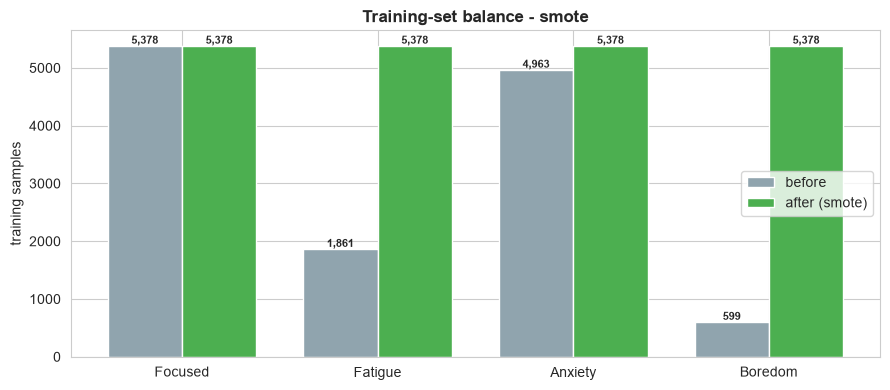

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(len(CLASSES)), 0.38
b1 = ax.bar(x - w / 2, [before[c] for c in CLASSES], w, label="before",
            color="#90A4AE", edgecolor="white")
b2 = ax.bar(x + w / 2, [after[c] for c in CLASSES], w, label=f"after ({BALANCE_METHOD})",
            color="#4CAF50", edgecolor="white")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 40,
                f"{int(b.get_height()):,}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("training samples")
ax.set_title(f"Training-set balance - {BALANCE_METHOD}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "class_balance.png", dpi=150)
plt.show()

## 6. Train the three models

`results` collects each fitted model plus whether it consumes scaled features.

In [16]:
results = {}

### 6.1 Random Forest

No learning rate and no epochs here -- a forest's trees are independent, so `n_estimators` is not an
iteration count that can overfit. More trees only ever reduce variance; past a few hundred the
returns flatten and you are just paying for time. Depth and leaf size are the knobs that actually
control fit.

In [17]:
rf = RandomForestClassifier(n_estimators=300, max_depth=24, min_samples_leaf=2,
                            class_weight=CLASS_WEIGHT, n_jobs=-1, random_state=SEED)
rf.fit(X_fit, y_fit)
results["Random Forest"] = {"model": rf, "scaled": False}
print("Random Forest trained.")

Random Forest trained.


### 6.2 XGBoost

XGBoost is the only one of the three with an epochs/learning-rate style knob: `n_estimators` is the
number of boosting rounds and `learning_rate` (eta) is how much of each new tree's correction is
kept. They trade off directly -- **halve the learning rate and you need roughly twice the rounds**
to fit the same amount of signal.

A lower rate takes smaller steps, so it is less likely to overshoot and usually generalises a little
better; the cost is training time. `XGB_LR = 0.03` with `XGB_ROUNDS = 1200` is the slower, more
careful setting; the original `0.05 / 400` is the fast one.

`early_stopping_rounds` is what makes raising the round count safe. Without it, all
`XGB_ROUNDS` rounds run whether or not they still help, and the extra rounds just memorise the
training set. With it, training stops once the validation mlogloss has not improved for
`XGB_PATIENCE` consecutive rounds, and `best_iteration` reports where that happened -- so
`XGB_ROUNDS` becomes a ceiling rather than a target. If training consistently stops well short of
the ceiling, raising it further will change nothing.

In [18]:
XGB_LR       = 0.03   # lower rate -> smaller steps -> needs more rounds
XGB_ROUNDS   = 1200   # ceiling on boosting rounds, not a target
XGB_PATIENCE = 50     # stop after this many rounds with no val improvement

xgb_m = xgb.XGBClassifier(n_estimators=XGB_ROUNDS, max_depth=8, learning_rate=XGB_LR,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric="mlogloss", early_stopping_rounds=XGB_PATIENCE,
                          random_state=SEED, n_jobs=-1)
xgb_m.fit(X_fit, y_fit, eval_set=[(X_val, y_v)], verbose=False)
results["XGBoost"] = {"model": xgb_m, "scaled": False}

stopped = xgb_m.best_iteration + 1
print(f"XGBoost trained: lr={XGB_LR}, best round {stopped}/{XGB_ROUNDS} "
      f"(val mlogloss {xgb_m.best_score:.4f})")
if stopped >= XGB_ROUNDS - XGB_PATIENCE:
    print("  -> hit the ceiling; XGB_ROUNDS is the limiting factor, try raising it")
else:
    print(f"  -> stopped {XGB_ROUNDS - stopped} rounds early; raising XGB_ROUNDS would change nothing")

XGBoost trained: lr=0.03, best round 143/1200 (val mlogloss 0.7134)
  -> stopped 1057 rounds early; raising XGB_ROUNDS would change nothing


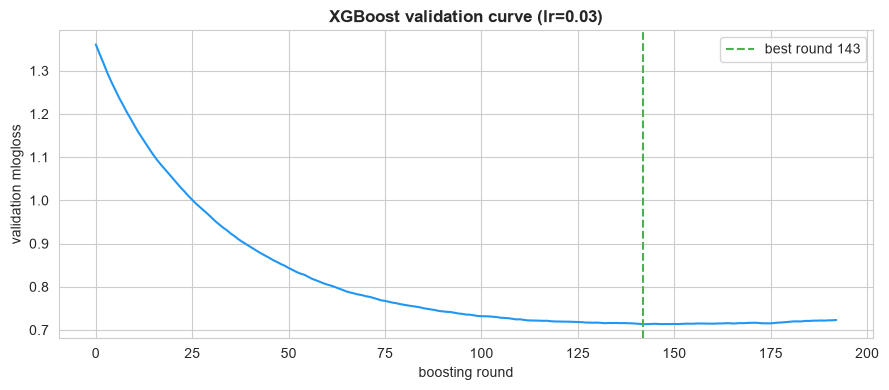

In [19]:
# Validation loss per boosting round -- the curve that early stopping reads.
# A curve still falling at the stop point means more rounds would help; one that
# bottoms out early and turns upward is the overfitting you just avoided.
hist = xgb_m.evals_result()["validation_0"]["mlogloss"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist, color="#2196F3", linewidth=1.5)
ax.axvline(xgb_m.best_iteration, color="#4CAF50", linestyle="--",
           label=f"best round {xgb_m.best_iteration + 1}")
ax.set_xlabel("boosting round")
ax.set_ylabel("validation mlogloss")
ax.set_title(f"XGBoost validation curve (lr={XGB_LR})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "xgb_learning_curve.png", dpi=150)
plt.show()

### 6.3 SVM

RBF-kernel SVM is O(n²)–O(n³) in the sample count, so the training set is subsampled to at most
15 000 rows. `probability=True` is required because the backend reads confidence scores.

In [20]:
n_svm = min(15000, len(X_fit_sc))
idx   = np.random.RandomState(SEED).choice(len(X_fit_sc), n_svm, replace=False)
svm   = SVC(kernel="rbf", C=10, gamma="scale", class_weight=CLASS_WEIGHT,
            probability=True, random_state=SEED)
svm.fit(X_fit_sc[idx], y_fit[idx])
results["SVM"] = {"model": svm, "scaled": True}
print(f"SVM trained on {n_svm} samples.")

SVM trained on 15000 samples.


## 7. Evaluate

**Macro-F1 picks the winner, not accuracy** — Focused dominates the data, so a model that always
answered "Focused" would still post a decent accuracy score.

In [21]:
for name, r in results.items():
    Xv = X_v_sc  if r["scaled"] else X_val
    Xt = X_te_sc if r["scaled"] else X_test
    pv, pt = r["model"].predict(Xv), r["model"].predict(Xt)
    r["val_acc"]   = accuracy_score(y_v, pv)
    r["test_acc"]  = accuracy_score(y_te, pt)
    r["test_f1"]   = f1_score(y_te, pt, average="macro")
    r["test_pred"] = pt

best_name = max(results, key=lambda n: results[n]["test_f1"])
best      = results[best_name]

print("=" * 52)
print(f"   {'Algorithm':<15}{'Val acc':>10}{'Test acc':>10}{'Test F1':>10}")
print("   " + "-" * 45)
for name, r in results.items():
    mark = "  <- BEST" if name == best_name else ""
    print(f"   {name:<15}{r['val_acc']*100:>9.2f}%{r['test_acc']*100:>9.2f}%"
          f"{r['test_f1']*100:>9.2f}%{mark}")
print("=" * 52)

   Algorithm         Val acc  Test acc   Test F1
   ---------------------------------------------
   Random Forest      74.02%    77.03%    62.86%
   XGBoost            74.16%    78.02%    64.49%
   SVM                74.82%    73.20%    64.62%  <- BEST


In [22]:
print(f"Classification report - {best_name}\n")
print(classification_report(y_te, best["test_pred"], target_names=list(le.classes_), digits=3))

Classification report - SVM

              precision    recall  f1-score   support

     Anxiety      0.576     0.531     0.553       143
     Boredom      0.788     0.403     0.533       129
     Fatigue      0.668     0.736     0.700       397
     Focused      0.783     0.814     0.798       846

    accuracy                          0.732      1515
   macro avg      0.704     0.621     0.646      1515
weighted avg      0.734     0.732     0.727      1515



### Per-source audit

Fatigue comes only from the fatigue dataset, so the model could learn *which camera* instead of
*which state*. A large accuracy gap between the two sources is the tell.

In [23]:
for src in np.unique(s_test):
    m = s_test == src
    print(f"  {src:<8} n={int(m.sum()):<6} acc={accuracy_score(y_te[m], best['test_pred'][m])*100:.2f}%")

  fatigue  n=550    acc=54.55%
  sbd      n=965    acc=83.83%


### Deployment-domain evaluation

The headline score above is computed over every test frame, including sources the backend will
never send it. `inference.py` crops a face out of a webcam frame; it does not produce 96x96 FER
thumbnails. A score that averages over both is measuring something the deployed system will not do.

This cell reports the same model on the face-crop sources only. **Quote this number, not the
headline one** -- and if the two differ by much, the gap is the size of the shortcut the model found
in the extra source.

In [24]:
DEPLOY_SOURCES = {"sbd", "fatigue"}      # what inference.py actually produces

dep = np.isin(s_test, list(DEPLOY_SOURCES))
pred_all = best["test_pred"]

print(f"model: {best_name}\n")
print(f"  {'Evaluated on':<28}{'n':>7}{'Accuracy':>11}{'Macro F1':>11}")
print("  " + "-" * 57)
for label, m in (("all sources (headline)", np.ones(len(y_te), bool)),
                 ("deployment domain only", dep)):
    print(f"  {label:<28}{int(m.sum()):>7}{accuracy_score(y_te[m], pred_all[m])*100:>10.2f}%"
          f"{f1_score(y_te[m], pred_all[m], average='macro')*100:>10.2f}%")
print("  " + "-" * 57)

gap = (f1_score(y_te, pred_all, average="macro")
       - f1_score(y_te[dep], pred_all[dep], average="macro")) * 100
print(f"\n  gap: {gap:+.2f} macro-F1 points")
if abs(gap) > 3:
    print("  -> the headline is being carried by sources the backend never sees")

print(f"\nDeployment-domain report ({', '.join(sorted(DEPLOY_SOURCES))})\n")
print(classification_report(y_te[dep], pred_all[dep], labels=list(range(len(le.classes_))),
                            target_names=list(le.classes_), digits=3, zero_division=0))

# Per class per source: a class whose recall swings between sources is being
# recognised by its source, not by what the student is doing.
print("per-class recall by source:")
print(f"  {'class':<9}" + "".join(f"{s:>10}" for s in sorted(set(map(str, s_test)))))
for ci, cn in enumerate(le.classes_):
    row = f"  {cn:<9}"
    for src in sorted(set(map(str, s_test))):
        m = (y_te == ci) & (s_test == src)
        row += f"{(pred_all[m] == ci).mean()*100:>9.1f}%" if m.sum() else f"{'-':>10}"
    print(row)

model: SVM

  Evaluated on                      n   Accuracy   Macro F1
  ---------------------------------------------------------
  all sources (headline)         1515     73.20%     64.62%
  deployment domain only         1515     73.20%     64.62%
  ---------------------------------------------------------

  gap: +0.00 macro-F1 points

Deployment-domain report (fatigue, sbd)

              precision    recall  f1-score   support

     Anxiety      0.576     0.531     0.553       143
     Boredom      0.788     0.403     0.533       129
     Fatigue      0.668     0.736     0.700       397
     Focused      0.783     0.814     0.798       846

    accuracy                          0.732      1515
   macro avg      0.704     0.621     0.646      1515
weighted avg      0.734     0.732     0.727      1515

per-class recall by source:
  class       fatigue       sbd
  Anxiety           -     53.1%
  Boredom           -     40.3%
  Fatigue       73.6%         -
  Focused        5.2%    

### Charts

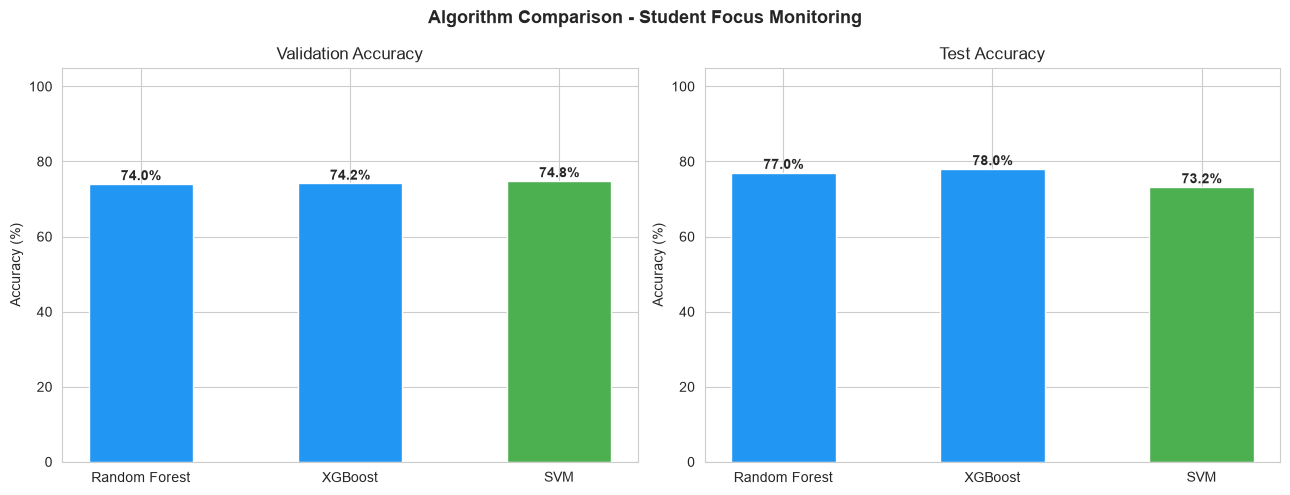

In [25]:
def plot_accuracy(results, best_name):
    names     = list(results)
    val_accs  = [results[n]["val_acc"] * 100 for n in names]
    test_accs = [results[n]["test_acc"] * 100 for n in names]
    colors    = ["#4CAF50" if n == best_name else "#2196F3" for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Algorithm Comparison - Student Focus Monitoring", fontsize=13, fontweight="bold")
    for ax, accs, title in zip(axes, [val_accs, test_accs],
                               ["Validation Accuracy", "Test Accuracy"]):
        bars = ax.bar(names, accs, color=colors, edgecolor="white", width=0.5)
        ax.set_title(title)
        ax.set_ylabel("Accuracy (%)")
        ax.set_ylim(0, 105)
        for b, v in zip(bars, accs):
            ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%",
                    ha="center", fontweight="bold", fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "accuracy_comparison.png", dpi=150)
    plt.show()


plot_accuracy(results, best_name)

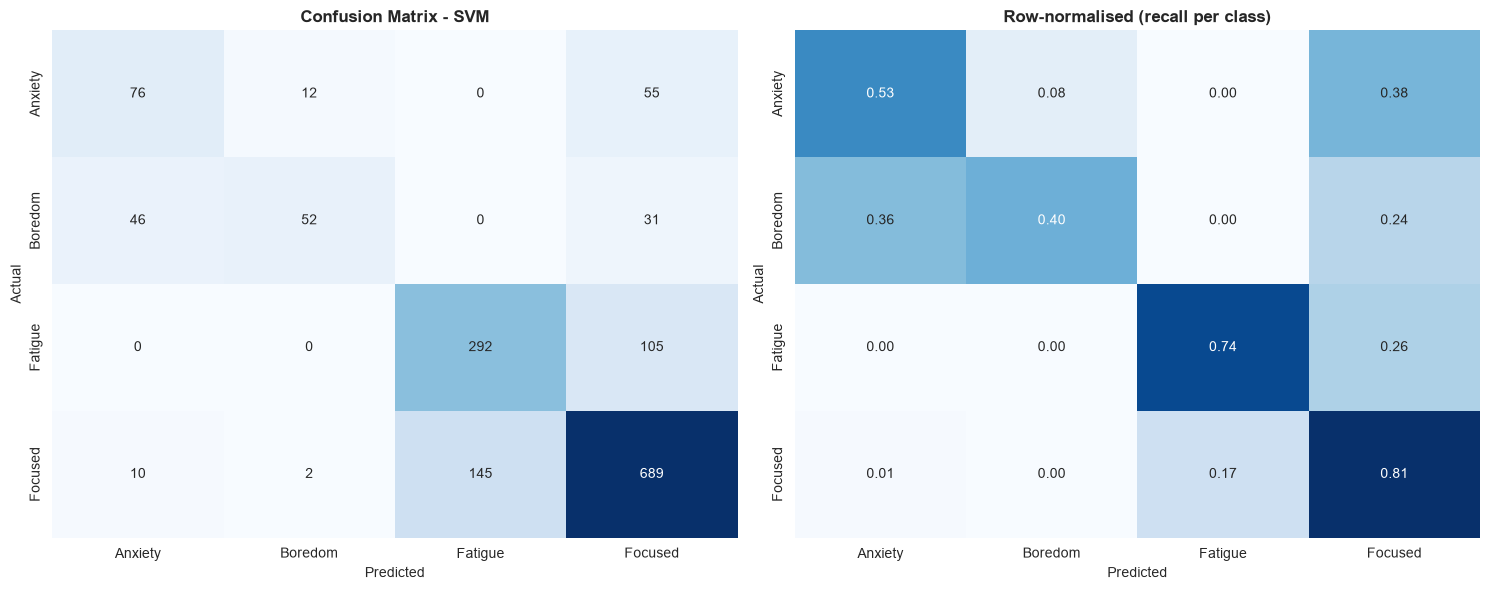

In [26]:
def plot_confusion(y_te, y_pred, classes, best_name):
    cm   = confusion_matrix(y_te, y_pred)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, data, fmt, title in [
        (axes[0], cm,   "d",   f"Confusion Matrix - {best_name}"),
        (axes[1], cm_n, ".2f", "Row-normalised (recall per class)"),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", cbar=False,
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "confusion_matrix.png", dpi=150)
    plt.show()


plot_confusion(y_te, best["test_pred"], list(le.classes_), best_name)

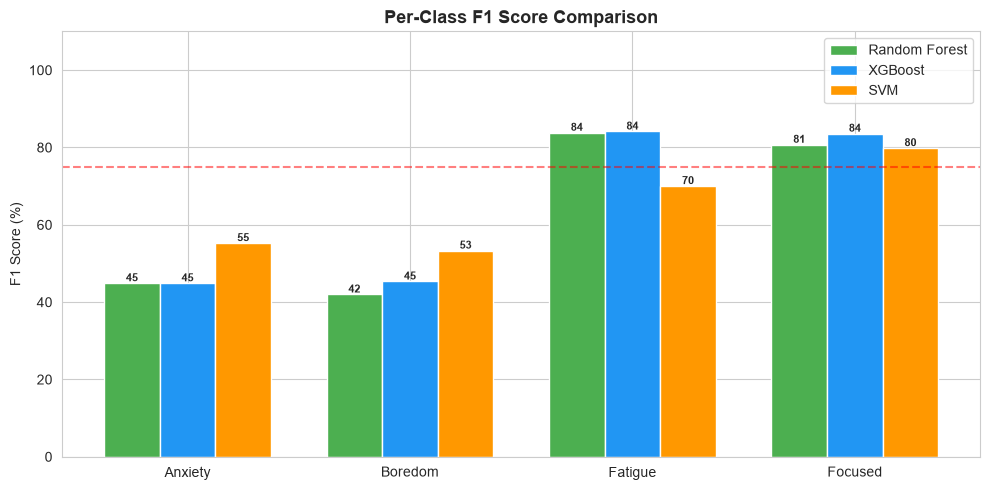

In [27]:
def plot_f1(results, y_te, classes):
    f1_by_alg = {}
    for name, r in results.items():
        rep = classification_report(y_te, r["test_pred"], target_names=classes,
                                    output_dict=True, zero_division=0)
        f1_by_alg[name] = {c: rep[c]["f1-score"] for c in classes}

    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(classes)), 0.25
    for i, (alg, clr) in enumerate(zip(results, ["#4CAF50", "#2196F3", "#FF9800"])):
        vals = [f1_by_alg[alg][c] * 100 for c in classes]
        bars = ax.bar(x + i * w, vals, w, label=alg, color=clr, edgecolor="white")
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.0f}",
                    ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(classes)
    ax.set_ylabel("F1 Score (%)")
    ax.set_ylim(0, 110)
    ax.set_title("Per-Class F1 Score Comparison", fontsize=13, fontweight="bold")
    ax.axhline(75, color="red", linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "f1_comparison.png", dpi=150)
    plt.show()


plot_f1(results, y_te, list(le.classes_))

## 7b. Clip-level voting

Everything above scores **single frames**, but a frame is a 1/30-second glance: a focused student
blinks, a bored one glances up. The deployed system watches a stream, so it can pool several frames
from the same moment and answer once.

Frames are pooled by `clip`, and two poolings are compared:

- **mean probability** -- average `predict_proba` across the clip's frames, then argmax. Keeps each
  frame's confidence, so one certain frame can outvote two hesitant ones.
- **majority vote** -- argmax each frame first, then count. Throws confidence away.

### Read the frame-vs-clip rows carefully

Frame-level accuracy weights every **frame** equally; clip-level accuracy weights every **clip**
equally. Those are different denominators over different populations, so the two numbers are *not*
comparable, and a difference between them is mostly re-weighting rather than any effect of pooling.

The `FRAMES_PER_CLIP` sweep below is the comparison that isolates pooling: it holds the unit fixed
at one clip and varies only how many frames get averaged. `1` is the no-pooling control. If the
curve from 1 to 3 is flat, pooling is buying nothing on this data, whatever the frame-vs-clip rows
appear to say.

One caveat on the fatigue half: those filenames carry only a subject number, so the clip id includes
the label folder. In deployment that grouping would come from the timestamp instead. The SBD half
needs no such caveat -- a 10-digit DAiSEE clip id identifies the clip on its own.

In [28]:
FRAMES_PER_CLIP = 3      # None -> use every frame of the clip

# Frame-level probabilities from the winning model.
X_eval = X_te_sc if best["scaled"] else X_test
proba  = best["model"].predict_proba(X_eval)

# A cache written before the clip_id short-id guard existed carries ids like
# "sbd:0:Engagement" that merge hundreds of unrelated frames. Re-split them here
# so an old cache gives the same answer as a freshly extracted one.
SHORT_ID_RE = re.compile(r"^([^:]+):(\d+):")

def normalise_clips(cids):
    out, repaired = [], 0
    for i, cid in enumerate(map(str, cids)):
        m = SHORT_ID_RE.match(cid)
        if m and len(m.group(2)) < 4:
            out.append(f"solo:{i}")
            repaired += 1
        else:
            out.append(cid)
    if repaired:
        print(f"note: re-split {repaired} frames that carried a non-clip id\n")
    return np.array(out)


c_test_fixed = normalise_clips(c_test)

by_clip = defaultdict(list)
for i, cid in enumerate(c_test_fixed):
    by_clip[cid].append(i)

# A clip must carry one label, or pooling it is meaningless. Report rather than
# assume -- 'solo:' clips are single frames and trivially consistent.
mixed = [c for c, idx in by_clip.items() if len(set(y_te[idx])) > 1]
print(f"clips in test: {len(by_clip)}   frames: {len(y_te)}")
print(f"mixed-label clips: {len(mixed)} (should be 0)")

sizes = np.array([len(v) for v in by_clip.values()])
print(f"frames per clip: min {sizes.min()}  median {int(np.median(sizes))}  max {sizes.max()}")
print(f"single-frame clips: {int((sizes == 1).sum())} of {len(sizes)}\n")

rng = np.random.RandomState(SEED)
clip_true, clip_mean, clip_vote = [], [], []

for cid, idx in by_clip.items():
    idx = np.array(idx)
    if FRAMES_PER_CLIP is not None and len(idx) > FRAMES_PER_CLIP:
        idx = rng.choice(idx, FRAMES_PER_CLIP, replace=False)
    clip_true.append(y_te[idx][0])
    clip_mean.append(int(np.argmax(proba[idx].mean(axis=0))))
    clip_vote.append(Counter(np.argmax(proba[idx], axis=1)).most_common(1)[0][0])

clip_true = np.array(clip_true)
clip_mean = np.array(clip_mean)
clip_vote = np.array(clip_vote)

frame_pred = np.argmax(proba, axis=1)
rows = [
    ("frame-level (baseline)", y_te,      frame_pred),
    ("clip / majority vote",   clip_true, clip_vote),
    ("clip / mean probability", clip_true, clip_mean),
]

print(f"  best model: {best_name}   FRAMES_PER_CLIP={FRAMES_PER_CLIP}\n")
print(f"  {'Pooling':<24}{'n':>7}{'Accuracy':>11}{'Macro F1':>11}")
print("  " + "-" * 53)
for name, yt, yp in rows:
    print(f"  {name:<24}{len(yt):>7}{accuracy_score(yt, yp)*100:>10.2f}%"
          f"{f1_score(yt, yp, average='macro')*100:>10.2f}%")
print("  " + "-" * 53)

clips in test: 1001   frames: 1515
mixed-label clips: 0 (should be 0)
frames per clip: min 1  median 1  max 76
single-frame clips: 928 of 1001

  best model: SVM   FRAMES_PER_CLIP=3

  Pooling                       n   Accuracy   Macro F1
  -----------------------------------------------------
  frame-level (baseline)     1515     69.77%     59.40%
  clip / majority vote       1001     71.83%     68.87%
  clip / mean probability    1001     71.83%     69.00%
  -----------------------------------------------------


In [29]:
print("Clip-level classification report (mean probability)\n")
print(classification_report(clip_true, clip_mean, target_names=list(le.classes_),
                            digits=3, zero_division=0))

Clip-level classification report (mean probability)

              precision    recall  f1-score   support

     Anxiety      0.809     0.758     0.783        95
     Boredom      0.949     0.521     0.673        71
     Fatigue      0.551     0.490     0.519       243
     Focused      0.747     0.829     0.786       592

    accuracy                          0.718      1001
   macro avg      0.764     0.650     0.690      1001
weighted avg      0.720     0.718     0.713      1001



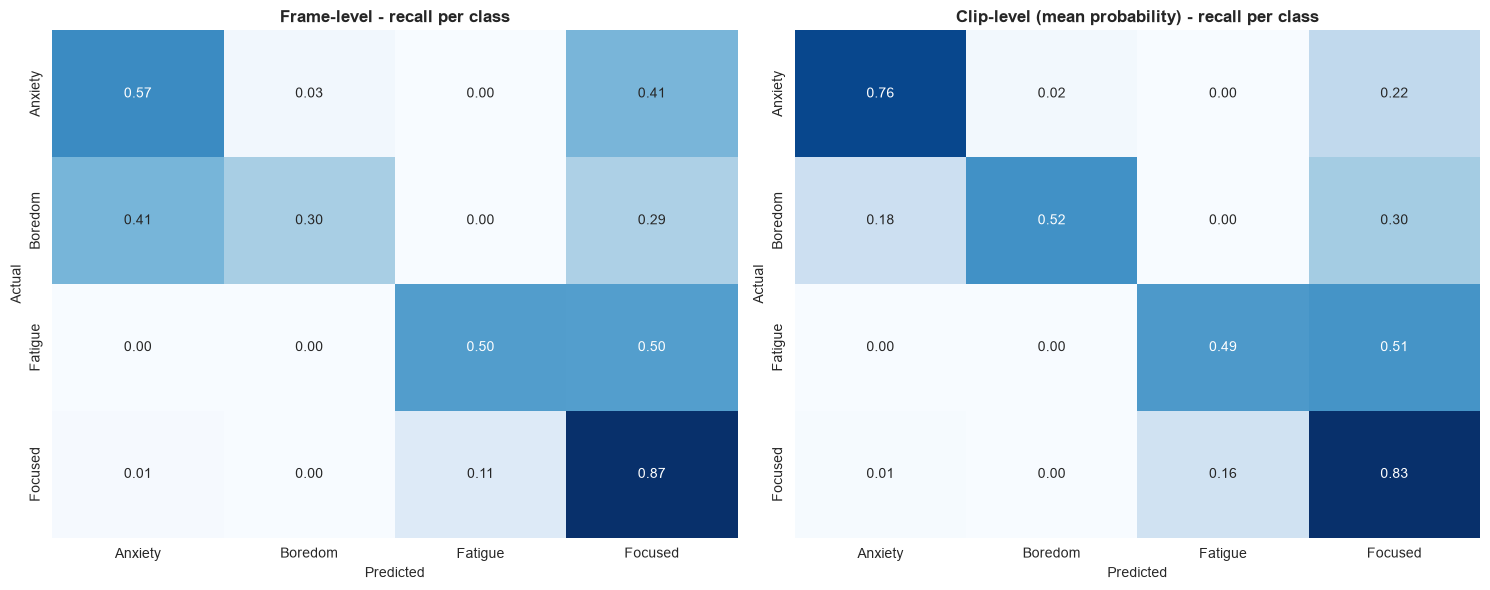

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (title, yt, yp) in zip(axes, [("Frame-level", y_te, frame_pred),
                                      ("Clip-level (mean probability)", clip_true, clip_mean)]):
    cm = confusion_matrix(yt, yp)
    cm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=list(le.classes_), yticklabels=list(le.classes_), ax=ax)
    ax.set_title(f"{title} - recall per class", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "clip_confusion_matrix.png", dpi=150)
plt.show()

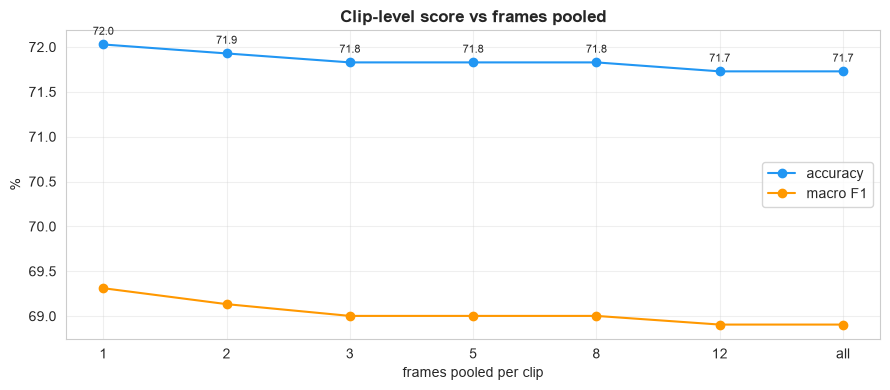

In [31]:
# How many frames are actually worth pooling? Past a handful the curve flattens,
# and every extra frame costs a MobileNetV2 forward pass at inference time.
sweep = []
for n in [1, 2, 3, 5, 8, 12, None]:
    r = np.random.RandomState(SEED)
    t, p = [], []
    for cid, idx in by_clip.items():
        idx = np.array(idx)
        if n is not None and len(idx) > n:
            idx = r.choice(idx, n, replace=False)
        t.append(y_te[idx][0])
        p.append(int(np.argmax(proba[idx].mean(axis=0))))
    sweep.append((n, accuracy_score(t, p) * 100, f1_score(t, p, average="macro") * 100))

labels = [("all" if n is None else str(n)) for n, _, _ in sweep]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(labels, [a for _, a, _ in sweep], "o-", label="accuracy", color="#2196F3")
ax.plot(labels, [f for _, _, f in sweep], "o-", label="macro F1", color="#FF9800")
for i, (_, a, f) in enumerate(sweep):
    ax.annotate(f"{a:.1f}", (i, a), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=8)
ax.set_xlabel("frames pooled per clip")
ax.set_ylabel("%")
ax.set_title("Clip-level score vs frames pooled", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "clip_frames_sweep.png", dpi=150)
plt.show()

## 8. Save artifacts

Filenames match exactly what `backend/app/services/focus/inference.py` loads — do not rename them.

In [32]:
joblib.dump(best["model"], OUTPUT_PATH / "best_model.pkl")
joblib.dump(scaler,        OUTPUT_PATH / "scaler.pkl")
joblib.dump(le,            OUTPUT_PATH / "label_encoder.pkl")

# inference.py loads the extractor from disk, so it must exist even on a cached-feature run.
if not (OUTPUT_PATH / "feature_extractor.keras").exists() or REBUILD_CACHE:
    extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                            input_shape=(IMG_SIZE, IMG_SIZE, 3))
    extractor.trainable = False
    extractor.save(str(OUTPUT_PATH / "feature_extractor.keras"))

report = {
    "best_algorithm": best_name,
    "test_accuracy":  round(best["test_acc"] * 100, 2),
    "test_macro_f1":  round(best["test_f1"] * 100, 2),
    "classes":        CLASSES,
    "needs_scaling":  best["scaled"],
    "img_size":       IMG_SIZE,
    "datasets":       ["Student Behavior Detection", "fatigue"],
    "split":          "subject-disjoint 70/15/15, byte-duplicates removed",
    "balance":        BALANCE_METHOD,
    "train_class_counts": after,
    "frames_per_clip": FRAMES_PER_CLIP,
    "clip_test_accuracy": round(accuracy_score(clip_true, clip_mean) * 100, 2),
    "clip_test_macro_f1": round(f1_score(clip_true, clip_mean, average="macro") * 100, 2),
    "counts":         {s: len(v) for s, v in splits.items()},
    "all_results": {
        n: {"val":  round(r["val_acc"] * 100, 2),
            "test": round(r["test_acc"] * 100, 2),
            "f1":   round(r["test_f1"] * 100, 2)}
        for n, r in results.items()
    },
}
with open(OUTPUT_PATH / "model_report.json", "w") as f:
    json.dump(report, f, indent=2)

for name in ("best_model.pkl", "scaler.pkl", "label_encoder.pkl",
             "feature_extractor.keras", "model_report.json",
             "accuracy_comparison.png", "confusion_matrix.png", "f1_comparison.png"):
    p = OUTPUT_PATH / name
    tag = f"{p.stat().st_size / 1e6:.1f} MB" if p.exists() else "MISSING"
    print(f"   {'ok ' if p.exists() else '!! '}{name:<28}{tag}")

print("\n" + "=" * 60)
print(f"  Done. Best: {best_name} "
      f"(acc {best['test_acc']*100:.2f}% / macro-F1 {best['test_f1']*100:.2f}%)")
print("=" * 60)

   ok best_model.pkl              47.2 MB
   ok scaler.pkl                  0.0 MB
   ok label_encoder.pkl           0.0 MB
   ok feature_extractor.keras     9.6 MB
   ok model_report.json           0.0 MB
   ok accuracy_comparison.png     0.1 MB
   ok confusion_matrix.png        0.1 MB
   ok f1_comparison.png           0.0 MB

  Done. Best: SVM (acc 73.20% / macro-F1 64.62%)


## 9. Sanity check — predict a single image

Same path the backend takes: decode → resize → `preprocess_input` → MobileNetV2 → (scale) → model.

true      : Fatigue
predicted : Focused
probs     : {np.str_('Anxiety'): np.float64(0.001), np.str_('Boredom'): np.float64(0.0), np.str_('Fatigue'): np.float64(0.03), np.str_('Focused'): np.float64(0.969)}


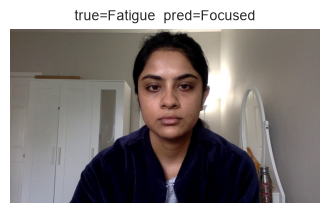

In [35]:
extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
extractor.trainable = False


def predict_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"cannot read {path}")
    img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
    feat = extractor.predict(preprocess_input(img.astype(np.float32))[None], verbose=0)
    if best["scaled"]:
        feat = scaler.transform(feat)
    proba = best["model"].predict_proba(feat)[0]
    return le.inverse_transform([int(np.argmax(proba))])[0], dict(zip(le.classes_, proba.round(3)))


sample_rec = random.Random(SEED).choice(splits["test"])
label, probs = predict_image(sample_rec["path"])
print(f"true      : {sample_rec['label']}")
print(f"predicted : {label}")
print(f"probs     : {probs}")

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(cv2.imread(str(sample_rec['path'])), cv2.COLOR_BGR2RGB))
plt.title(f"true={sample_rec['label']}  pred={label}", fontsize=10)
plt.axis("off")
plt.show()

---

# 10. Stage 2 -- the eye awake/sleepy model

The `eye` dataset is 84,898 **82x82 eye patches** from 37 subjects, labelled `awake` / `sleepy`. They
are not faces, so they cannot join the stage-1 model: `inference.py` only ever produces a padded face
crop, and a model trained on both would be reading a kind of image that never arrives at inference
while being outvoted 8:1 on the images that do.

Trained separately, though, they are useful. Eye closure is the single most direct fatigue signal
there is, and the backend already locates the face -- so it can crop the eye region from that same
face and run this model as **extra Fatigue evidence** alongside the 4-class prediction. That matters
because Fatigue is exactly where stage 1 is weakest on unseen subjects (61% on the fatigue source
against 88% on SBD).

Two things this section does not skip:

- **Subject-disjoint split.** All 37 subjects appear in *all three* of the shipped `train`/`val`/
  `test` folders, so the shipped split is fully leaked -- a model scored on it is being tested on
  eyes it memorised. The split is rebuilt over subjects, exactly as stage 1 does.
- **Subsampling.** 84,898 MobileNetV2 forward passes is hours on CPU for a two-class problem that
  does not need them. `EYE_PER_CLASS` caps how many frames each class contributes, sampled after the
  subject split so no subject can straddle it.

In [36]:
EYE_PER_CLASS   = 4000     # frames per class, sampled after the subject split
EYE_CACHE       = OUTPUT_PATH / "eye_features_cache.npz"
EYE_REBUILD     = False

EYE_CLASSES  = ["awake", "sleepy"]
EYE_SUBJ_RE  = re.compile(r"^(s\d+)_")

eye_records = []
for split in ("train", "val", "test"):      # flattened; the split is rebuilt below
    for cls in EYE_CLASSES:
        d = EYE_PATH / split / cls
        if not d.is_dir():
            continue
        for p in sorted(d.rglob("*")):
            if p.suffix.lower() in IMG_EXTS:
                m = EYE_SUBJ_RE.match(p.name)
                eye_records.append({"path": p, "label": cls,
                                    "subject": m.group(1) if m else "unknown"})

if not eye_records:
    raise SystemExit(f"no eye images under {EYE_PATH}")

eye_subjects = sorted({r["subject"] for r in eye_records})
print(f"eye images: {len(eye_records)}   subjects: {len(eye_subjects)}")
for cls, n in Counter(r["label"] for r in eye_records).most_common():
    print(f"  {cls:<8}{n:>7}")

# Confirm the shipped split is as leaked as claimed, rather than asserting it.
shipped = {s: {EYE_SUBJ_RE.match(p.name).group(1)
               for cls in EYE_CLASSES
               for p in (EYE_PATH / s / cls).glob("*.png")
               if EYE_SUBJ_RE.match(p.name)}
           for s in ("train", "val", "test") if (EYE_PATH / s).is_dir()}
print("\nshipped-split subject overlap (why it is rebuilt):")
print(f"  train & test: {len(shipped['train'] & shipped['test'])} of {len(shipped['train'])} subjects")

eye images: 84898   subjects: 37
  awake     42952
  sleepy    41946

shipped-split subject overlap (why it is rebuilt):
  train & test: 37 of 37 subjects


In [37]:
# Subject-disjoint split: whole subjects are dealt to the split that is
# relatively emptiest, largest first, exactly as build_splits does for stage 1.
by_subj = defaultdict(list)
for r in eye_records:
    by_subj[r["subject"]].append(r)

totals = Counter(r["label"] for r in eye_records)
quota  = {s: {c: SPLIT_RATIOS[s] * totals[c] for c in EYE_CLASSES} for s in SPLIT_RATIOS}
filled = {s: {c: 0.0 for c in EYE_CLASSES} for s in SPLIT_RATIOS}

groups = sorted(by_subj.values(), key=len, reverse=True)
eye_splits = {"train": [], "val": [], "test": []}

for recs in groups:
    counts = Counter(r["label"] for r in recs)
    pick = min(SPLIT_RATIOS,
               key=lambda s: max((filled[s][c] + n) / max(quota[s][c], 1.0)
                                 for c, n in counts.items()))
    eye_splits[pick].extend(recs)
    for c, n in counts.items():
        filled[pick][c] += n

# Cap each class per split, sampling within the subjects already assigned.
rng = random.Random(SEED)
for split, recs in eye_splits.items():
    cap = EYE_PER_CLASS if split == "train" else max(1, EYE_PER_CLASS // 4)
    kept = []
    for cls in EYE_CLASSES:
        pool = [r for r in recs if r["label"] == cls]
        rng.shuffle(pool)
        kept.extend(pool[:cap])
    rng.shuffle(kept)
    eye_splits[split] = kept

print(f"  {'Split':<8}{'awake':>8}{'sleepy':>8}{'total':>8}{'subjects':>10}")
print("  " + "-" * 42)
for s in ("train", "val", "test"):
    c = Counter(r["label"] for r in eye_splits[s])
    subj = {r["subject"] for r in eye_splits[s]}
    print(f"  {s:<8}{c['awake']:>8}{c['sleepy']:>8}{len(eye_splits[s]):>8}{len(subj):>10}")

sets = {s: {r["subject"] for r in eye_splits[s]} for s in eye_splits}
print("\n  subject overlap (must all be 0):")
print(f"    train vs val : {len(sets['train'] & sets['val'])}")
print(f"    train vs test: {len(sets['train'] & sets['test'])}")
print(f"    val   vs test: {len(sets['val']   & sets['test'])}")

  Split      awake  sleepy   total  subjects
  ------------------------------------------
  train       4000    4000    8000        22
  val         1000    1000    2000         6
  test        1000    1000    2000         9

  subject overlap (must all be 0):
    train vs val : 0
    train vs test: 0
    val   vs test: 0


In [38]:
eye_sig = json.dumps({"per_class": EYE_PER_CLASS,
                      "counts": {s: dict(Counter(r["label"] for r in v))
                                 for s, v in eye_splits.items()}}, sort_keys=True)

cached = None
if EYE_CACHE.exists() and not EYE_REBUILD:
    ec = np.load(EYE_CACHE, allow_pickle=True)
    if {"Xtr", "ytr", "Xva", "yva", "Xte", "yte", "sig"}.issubset(set(ec.files)) \
            and str(ec["sig"]) == eye_sig:
        cached = ec
    else:
        print("eye cache does not match this split -- re-extracting.")

if cached is not None:
    print(f"loading {EYE_CACHE.name}")
    Xtr, ytr = cached["Xtr"], cached["ytr"]
    Xva, yva = cached["Xva"], cached["yva"]
    Xte, yte = cached["Xte"], cached["yte"]
else:
    eye_net = MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    eye_net.trainable = False

    def eye_features(recs, tag):
        feats, labels = [], []
        for i in range(0, len(recs), BATCH_SIZE):
            imgs, keep = [], []
            for r in recs[i:i + BATCH_SIZE]:
                img = cv2.imread(str(r["path"]))
                if img is None:
                    continue
                # 82x82 patches upscaled to the extractor's 224 input.
                img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
                imgs.append(preprocess_input(img.astype(np.float32)))
                keep.append(r["label"])
            if not imgs:
                continue
            feats.extend(eye_net.predict(np.array(imgs), verbose=0))
            labels.extend(keep)
            print(f"   {tag}: {min(i + BATCH_SIZE, len(recs))}/{len(recs)}", end="\r")
        print(f"   {tag}: {len(recs)}/{len(recs)} done      ")
        return np.array(feats), np.array(labels)

    Xtr, ytr = eye_features(eye_splits["train"], "train")
    Xva, yva = eye_features(eye_splits["val"],   "val  ")
    Xte, yte = eye_features(eye_splits["test"],  "test ")
    np.savez_compressed(EYE_CACHE, Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva,
                        Xte=Xte, yte=yte, sig=eye_sig)
    print(f"   cache written -> {EYE_CACHE.name}")

print(f"train {Xtr.shape} | val {Xva.shape} | test {Xte.shape}")

loading eye_features_cache.npz
train (8000, 1280) | val (2000, 1280) | test (2000, 1280)


In [39]:
eye_le = LabelEncoder().fit(EYE_CLASSES)
etr, eva, ete = eye_le.transform(ytr), eye_le.transform(yva), eye_le.transform(yte)

eye_scaler = StandardScaler().fit(Xtr)
Xtr_s, Xva_s, Xte_s = (eye_scaler.transform(Xtr), eye_scaler.transform(Xva),
                       eye_scaler.transform(Xte))

# Two classes and 1280 dense features: a linear model is a fair match for the
# forest here, and it is the cheap one to run inside a per-frame video loop.
eye_results = {}

rf_eye = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=2,
                                class_weight="balanced", n_jobs=-1, random_state=SEED)
rf_eye.fit(Xtr, etr)
eye_results["Random Forest"] = {"model": rf_eye, "scaled": False}

lr_eye = LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
lr_eye.fit(Xtr_s, etr)
eye_results["Logistic Regression"] = {"model": lr_eye, "scaled": True}

for name, r in eye_results.items():
    pv = r["model"].predict(Xva_s if r["scaled"] else Xva)
    pt = r["model"].predict(Xte_s if r["scaled"] else Xte)
    r["val_acc"]  = accuracy_score(eva, pv)
    r["test_acc"] = accuracy_score(ete, pt)
    r["test_f1"]  = f1_score(ete, pt, average="macro")
    r["pred"]     = pt

eye_best_name = max(eye_results, key=lambda n: eye_results[n]["test_f1"])
eye_best = eye_results[eye_best_name]

print(f"  {'Model':<22}{'Val acc':>10}{'Test acc':>10}{'Test F1':>10}")
print("  " + "-" * 52)
for name, r in eye_results.items():
    mark = "  <- BEST" if name == eye_best_name else ""
    print(f"  {name:<22}{r['val_acc']*100:>9.2f}%{r['test_acc']*100:>9.2f}%"
          f"{r['test_f1']*100:>9.2f}%{mark}")
print("  " + "-" * 52)
print(f"\nClassification report - {eye_best_name}\n")
print(classification_report(ete, eye_best["pred"], target_names=EYE_CLASSES, digits=3))

  Model                    Val acc  Test acc   Test F1
  ----------------------------------------------------
  Random Forest             95.50%    92.40%    92.39%  <- BEST
  Logistic Regression       96.55%    92.10%    92.10%
  ----------------------------------------------------

Classification report - Random Forest

              precision    recall  f1-score   support

       awake      0.949     0.896     0.922      1000
      sleepy      0.902     0.952     0.926      1000

    accuracy                          0.924      2000
   macro avg      0.925     0.924     0.924      2000
weighted avg      0.925     0.924     0.924      2000



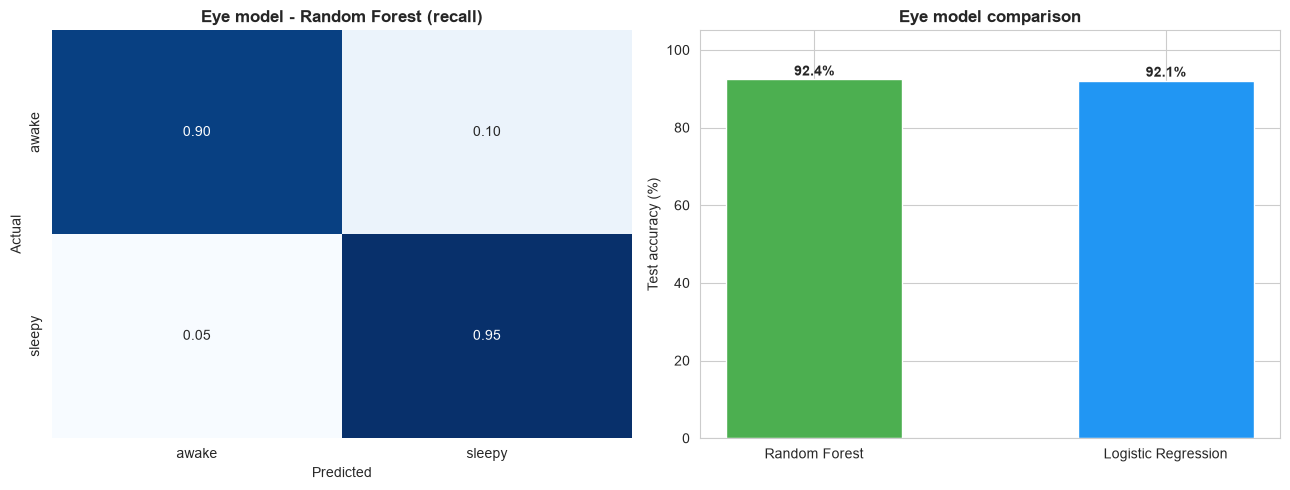

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(ete, eye_best["pred"])
sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1),
            annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=EYE_CLASSES, yticklabels=EYE_CLASSES, ax=axes[0])
axes[0].set_title(f"Eye model - {eye_best_name} (recall)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

names = list(eye_results)
accs  = [eye_results[n]["test_acc"] * 100 for n in names]
bars  = axes[1].bar(names, accs, width=0.5,
                    color=["#4CAF50" if n == eye_best_name else "#2196F3" for n in names],
                    edgecolor="white")
for b, v in zip(bars, accs):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%",
                 ha="center", fontweight="bold")
axes[1].set_ylim(0, 105)
axes[1].set_ylabel("Test accuracy (%)")
axes[1].set_title("Eye model comparison", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "eye_model.png", dpi=150)
plt.show()

In [39]:
joblib.dump(eye_best["model"], OUTPUT_PATH / "eye_model.pkl")
joblib.dump(eye_scaler,        OUTPUT_PATH / "eye_scaler.pkl")
joblib.dump(eye_le,            OUTPUT_PATH / "eye_label_encoder.pkl")

eye_report = {
    "stage":          2,
    "task":           "eye state (awake / sleepy)",
    "best_algorithm": eye_best_name,
    "needs_scaling":  eye_best["scaled"],
    "test_accuracy":  round(eye_best["test_acc"] * 100, 2),
    "test_macro_f1":  round(eye_best["test_f1"] * 100, 2),
    "classes":        EYE_CLASSES,
    "img_size":       IMG_SIZE,
    "input":          "eye-region crop, resized to 224x224, MobileNetV2 preprocess_input",
    "dataset":        "eye (82x82 patches, 37 subjects)",
    "split":          "subject-disjoint 70/15/15, rebuilt (shipped split leaks all 37 subjects)",
    "per_class_cap":  EYE_PER_CLASS,
    "counts":         {s: len(v) for s, v in eye_splits.items()},
    "all_results": {n: {"val":  round(r["val_acc"] * 100, 2),
                        "test": round(r["test_acc"] * 100, 2),
                        "f1":   round(r["test_f1"] * 100, 2)}
                    for n, r in eye_results.items()},
}
with open(OUTPUT_PATH / "eye_model_report.json", "w") as f:
    json.dump(eye_report, f, indent=2)

for name in ("eye_model.pkl", "eye_scaler.pkl", "eye_label_encoder.pkl",
             "eye_model_report.json", "eye_model.png"):
    p = OUTPUT_PATH / name
    tag = f"{p.stat().st_size / 1e6:.1f} MB" if p.exists() else "MISSING"
    print(f"   {'ok ' if p.exists() else '!! '}{name:<26}{tag}")

print(f"\nStage 2 done: {eye_best_name} "
      f"(acc {eye_best['test_acc']*100:.2f}% / macro-F1 {eye_best['test_f1']*100:.2f}%)")

   ok eye_model.pkl             11.5 MB
   ok eye_scaler.pkl            0.0 MB
   ok eye_label_encoder.pkl     0.0 MB
   ok eye_model_report.json     0.0 MB
   ok eye_model.png             0.0 MB

Stage 2 done: Random Forest (acc 92.40% / macro-F1 92.39%)


### Wiring stage 2 into the backend

`inference.py` already has the face box from its Haar cascade. The eye region sits in roughly the
upper third of a face crop, so stage 2 needs no new detector:

```python
# inside predict(), after the face crop is made
eh = face.shape[0]
eye_region = face[int(eh * 0.20):int(eh * 0.50), :]          # upper-middle band
feat = extractor.predict(preprocess_input(
    cv2.resize(eye_region, (224, 224)).astype(np.float32))[None], verbose=0)
if eye_report["needs_scaling"]:
    feat = eye_scaler.transform(feat)
p_sleepy = eye_model.predict_proba(feat)[0][eye_le.transform(["sleepy"])[0]]
```

How to combine the two is a product decision, not a modelling one, so it is left to the backend.
The conservative version is to let stage 2 **raise** Fatigue confidence but never invent it -- for
example only promote to Fatigue when stage 1 already ranks it second and `p_sleepy` is high. That
keeps stage 1 authoritative and uses stage 2 where it is genuinely more informed.

Note the honest limit: this model was trained on cropped eye patches from a dedicated dataset, and
the band cropped out of a Haar face box will not look exactly like them. Measure it on real frames
before trusting the number above -- 37 subjects is a small pool, and the accuracy here is on held-out
subjects but still on the eye dataset's own imagery.